# AML s26 - OLS / Ridge / LASSO comparison 

### Import Libraries

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns

### Load data and list feature names

In [10]:
df = pd.read_csv('data_ridge_lasso.csv')
X = df.drop('Y', axis=1).values
y = df['Y'].values

feature_names = df.drop('Y', axis=1).columns.values.tolist()
print('fn ', feature_names)

print(f"\nDataset: {X.shape[0]} samples, {X.shape[1]} features")

fn  ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13']

Dataset: 300 samples, 13 features


### Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Standardize features

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Train all 3 models

Note: parameter "alpha" is equal to $\lambda$

In [13]:
# Ordinary Least Squares
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Lasso Regression
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### Make predictions

In [14]:
models = {
    'OLS': ols,
    'Ridge (α=1.0)': ridge,
    'Lasso (α=0.1)': lasso
}

print("\nModel Performance:")
print("-" * 60)
print(f"{'Model':<20} {'Train MSE':>12} {'Test MSE':>12} {'Test R²':>12}")
print("-" * 60)

for name, model in models.items():
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    print(f"{name:<20} {train_mse:>12.3f} {test_mse:>12.3f} {test_r2:>12.4f}")




Model Performance:
------------------------------------------------------------
Model                   Train MSE     Test MSE      Test R²
------------------------------------------------------------
OLS                         3.795        3.629       0.8706
Ridge (α=1.0)               3.804        3.651       0.8699
Lasso (α=0.1)               3.883        3.623       0.8709


### Show model coefficients and L2 norm of coefficients

In [15]:
print(f"\nCoefficient Magnitude (L2 norm) and coefficients:")
print("-" * 90)
print(f"  OLS:   {np.linalg.norm(ols.coef_):.3f}")
print("Coefficients: ", ols.coef_)
print("-" * 90)
print(f"  Ridge: {np.linalg.norm(ridge.coef_):.3f}")
print("Coefficients: ", ridge.coef_)
print("-" * 90)
print(f"  Lasso: {np.linalg.norm(lasso.coef_):.3f}")
print("Coefficients: ", lasso.coef_)
print("-" * 90)


Coefficient Magnitude (L2 norm) and coefficients:
------------------------------------------------------------------------------------------
  OLS:   6.560
Coefficients:  [ 5.36857267 -2.97951873  1.95528435 -0.68902472  0.97113417 -0.01040294
 -0.0238465  -0.03256026  0.1648929  -0.12262267  0.00615371  0.13126929
  0.17363378]
------------------------------------------------------------------------------------------
  Ridge: 6.138
Coefficients:  [ 5.3406566  -1.96420427  1.95044307 -1.11764825  0.38000647 -0.00870323
 -0.02386393 -0.02811729  0.17736028 -0.11276487 -0.01231128  0.12769169
  0.17669215]
------------------------------------------------------------------------------------------
  Lasso: 5.959
Coefficients:  [ 5.24720325 -2.01374894  1.88451736 -0.59363227 -0.          0.
 -0.          0.          0.09189724 -0.02164241 -0.          0.03710775
  0.06957741]
------------------------------------------------------------------------------------------


### Compute correlation of features

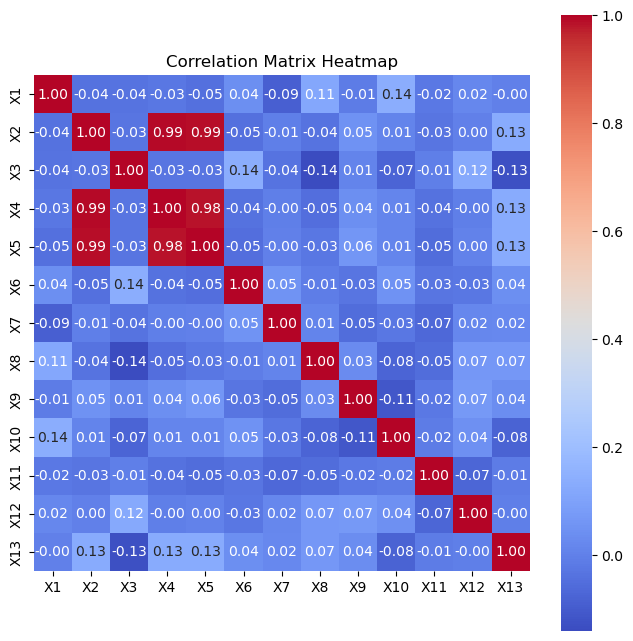

In [16]:
corr_matrix = df.drop('Y', axis=1).corr()

plt.figure(figsize=(8, 8))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix Heatmap")
plt.show()


### Compare model coefficients

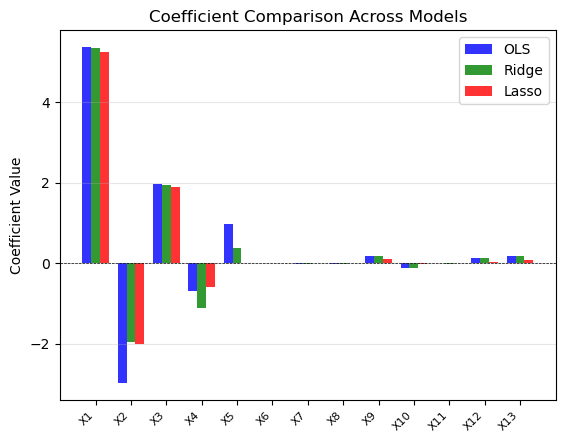

In [20]:
fig, ax =  plt.subplots()
x_pos = np.arange(len(feature_names))
width = 0.25

plt.bar(x_pos - width, ols.coef_, width, label='OLS', alpha=0.8, color='blue')
plt.bar(x_pos, ridge.coef_, width, label='Ridge', alpha=0.8, color='green')
plt.bar(x_pos + width, lasso.coef_, width, label='Lasso', alpha=0.8, color='red')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Coefficient Value')
plt.title('Coefficient Comparison Across Models')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.show()


### Impact of regularization as a function of $\alpha$ (&rarr;  $\lambda$)

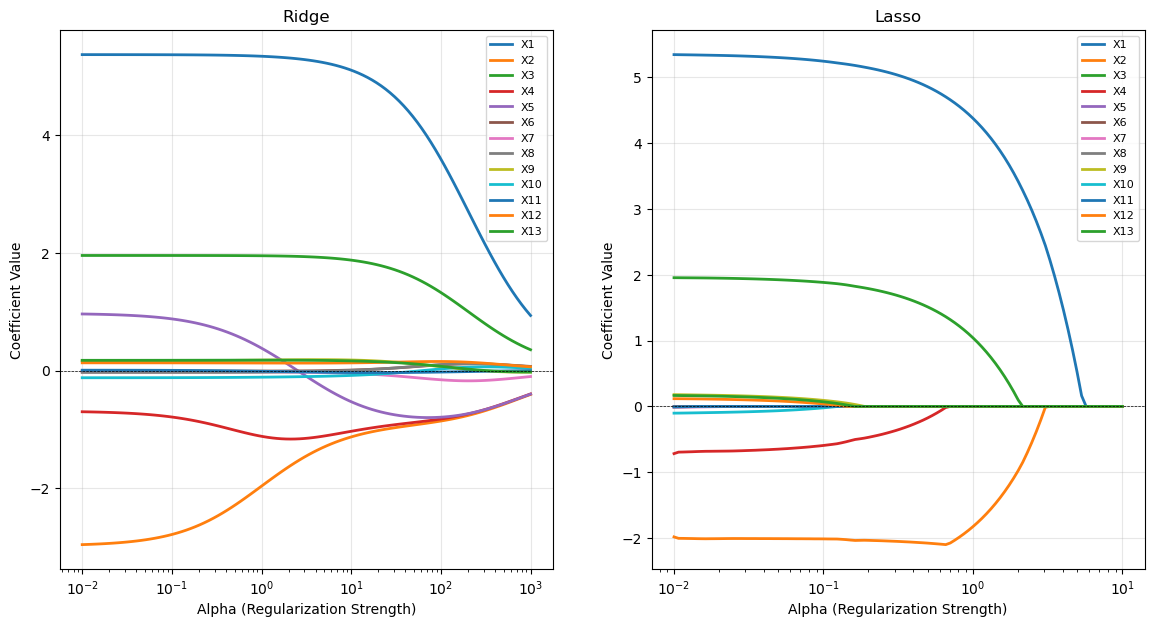

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Ridge regularization
ax1 = axes[0]
alphas = np.logspace(-2, 3, 100)
coefs_ridge = []

for alpha in alphas:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train_scaled, y_train)
    coefs_ridge.append(ridge_temp.coef_)

coefs_ridge = np.array(coefs_ridge)

# Plot coefficients
for i in range(len(feature_names)):  
    ax1.plot(alphas, coefs_ridge[:, i], label=feature_names[i], linewidth=2)


ax1.set_xscale('log')
ax1.set_xlabel('Alpha (Regularization Strength)')
ax1.set_ylabel('Coefficient Value')
ax1.set_title('Ridge')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Lasso regularization
ax2 = axes[1]

alphas_lasso = np.logspace(-2, 1, 100)
coefs_lasso = []

for alpha in alphas_lasso:
    lasso_temp = Lasso(alpha=alpha, max_iter=10000)
    lasso_temp.fit(X_train_scaled, y_train)
    coefs_lasso.append(lasso_temp.coef_)

coefs_lasso = np.array(coefs_lasso)

# Plot coefficients
for i in range(len(feature_names)): 
    ax2.plot(alphas_lasso, coefs_lasso[:, i], label=feature_names[i], linewidth=2)

ax2.set_xscale('log')
ax2.set_xlabel('Alpha (Regularization Strength)')
ax2.set_ylabel('Coefficient Value')
ax2.set_title('Lasso')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='--', linewidth=0.5)


Instability in the coefficient X5 due to correlations in corelation matrix; leads to Ridge being unstable with correlated data.

### Plot test error vs alpha

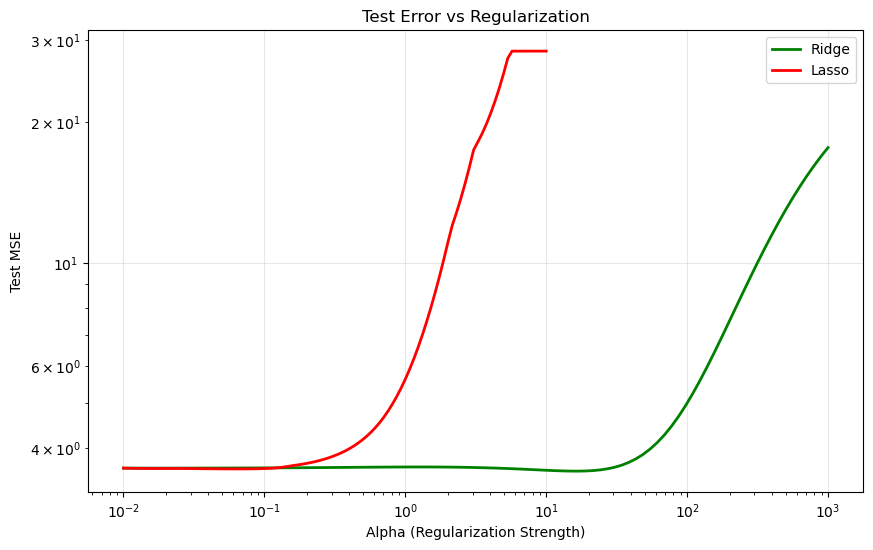

In [19]:
plt.figure(figsize=(10,6))
test_mse_ridge = []
test_mse_lasso = []

for alpha in alphas:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train_scaled, y_train)
    test_mse_ridge.append( mean_squared_error(y_test, ridge_temp.predict(X_test_scaled)) )

for alpha in alphas_lasso:
    lasso_temp = Lasso(alpha=alpha, max_iter=10000)
    lasso_temp.fit(X_train_scaled, y_train)
    test_mse_lasso.append( mean_squared_error(y_test, lasso_temp.predict(X_test_scaled)) )

plt.plot(alphas, test_mse_ridge, label='Ridge', linewidth=2, color='green')
plt.plot(alphas_lasso, test_mse_lasso, label='Lasso', linewidth=2, color='red')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Test MSE')
plt.title('Test Error vs Regularization')
plt.legend()
plt.grid(True, alpha=0.3)
